<a href="https://colab.research.google.com/github/Richajain02/assignment-02-bitsom_ba_2511757/blob/main/embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from google.colab import userdata
from huggingface_hub import login
token=userdata.get('HF_TOKEN')
login(token=token)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


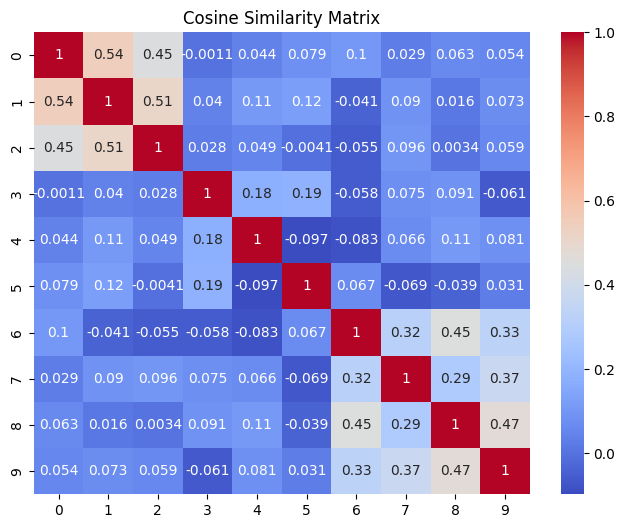

Sentence: The cricket match went down to the final over.
Similarity Score: 0.574236

Sentence: The bowler delivered a fast yorker to dismiss the batsman.
Similarity Score: 0.57212853



In [10]:
!pip install sentence-transformers seaborn matplotlib scikit-learn
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sentences = [
    # Cricket
    "The batsman hit a powerful six over long-on.",
    "The bowler delivered a fast yorker to dismiss the batsman.",
    "The cricket match went down to the final over.",

    # Cooking
    "I added garlic and butter to the pan to make the sauce.",
    "The chef baked a chocolate cake in the oven.",
    "Fresh vegetables are essential for a healthy salad.",

    # Cybersecurity
    "Strong passwords help protect accounts from hackers.",
    "A firewall prevents unauthorized access to the network.",
    "Phishing attacks try to trick users into revealing personal data.",
    "Encryption secures sensitive information during transmission."
]

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)
similarity_matrix = cosine_similarity(embeddings)
plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, cmap="coolwarm")
plt.title("Cosine Similarity Matrix")
plt.show()
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

query_similarity = cosine_similarity(query_embedding, embeddings)[0]
top_indices = np.argsort(query_similarity)[::-1][:2]

for idx in top_indices:
    print("Sentence:", sentences[idx])
    print("Similarity Score:", query_similarity[idx])
    print()